# Colorectal Cancer RNA-seq Differential Expression Analysis
**Dataset:** GSE292858 - Batch-corrected TPM counts (CRC tumor vs. normal tissue)  
**Pipeline:** Log2 normalization → Welch's t-test → BH FDR correction → Volcano plot → PCA → KEGG pathway enrichment → Heatmaps

## 1. Load Expression Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "E:/Python Projects/colorectal_cancer_rna_seq/data/GSE292858_CRC_batch1and2_bcorrected_TPM_count.txt"
SOFT_PATH = "E:/Python Projects/colorectal_cancer_rna_seq/data/GSE292858_family.soft"

df = pd.read_csv(DATA_PATH, sep="\t", index_col=0)

print(f"Expression matrix shape: {df.shape[0]:,} genes × {df.shape[1]:,} samples")
df.head()

Expression matrix shape: 26,426 genes × 73 samples


,CV020_N,CV021_N,CV023_N,CV025_N,CV026_N,CV028_N,CV030_N,CV031_N,CV033_N,CV034N,...,CRC2795_N,CRC2801_N,CRC2803_N,CRC2810_N,CRC2811_N,CRC2816_N,CRC2817_N,CRC2821_N_2,CRC2841_N_1,CRC2899_N
A1BG,1.36,1.23,1.94,1.00,1.15,1.48,1.51,1.03,0.66,1.61,...,1.54,1.84,1.07,0.76,0.90,1.04,0.87,2.32,1.02,1.42
A1BG-AS1,1.36,1.57,1.69,2.23,2.11,1.56,1.92,1.49,1.93,0.98,...,0.95,2.03,0.33,0.35,0.46,1.19,1.11,2.72,0.45,0.73
A1CF,15.83,15.98,18.78,36.28,28.51,64.68,19.72,29.25,44.71,11.95,...,22.26,25.85,1.27,11.28,1.34,22.69,22.22,31.34,2.98,33.24
A2M,338.57,476.10,494.99,330.12,483.69,349.72,454.25,546.36,520.40,231.24,...,271.86,246.55,517.08,391.79,343.85,298.72,316.07,268.25,805.47,102.80
A2M-AS1,1.02,0.62,3.29,4.32,3.35,1.31,1.57,2.38,2.07,0.48,...,1.96,0.76,5.42,3.12,6.10,1.60,2.05,1.25,7.50,0.16


## 2. Parse Sample Metadata from SOFT File

In [2]:
sample_ids, sample_names, tissues, batches = [], [], [], []
current_sample = current_name = current_tissue = current_batch = None

with open(SOFT_PATH, 'r') as f:
    for line in f:
        if line.startswith("^SAMPLE"):
            if current_sample is not None:
                sample_ids.append(current_sample)
                sample_names.append(current_name)
                tissues.append(current_tissue)
                batches.append(current_batch)
            current_sample = line.split("=")[1].strip()
            current_name = current_tissue = current_batch = None
        elif line.startswith("!Sample_title"):
            current_name = line.split("=")[1].strip()
        elif "tissue:" in line.lower():
            current_tissue = line.split("tissue:")[1].strip()
        elif "batch:" in line.lower():
            current_batch = line.split("batch:")[1].strip()

# Append last sample
sample_ids.append(current_sample)
sample_names.append(current_name)
tissues.append(current_tissue)
batches.append(current_batch)

meta = pd.DataFrame({
    "Sample_ID": sample_ids,
    "Sample_Name": sample_names,
    "Tissue": tissues,
    "Batch": batches
})

print(f"Total samples in metadata: {len(meta)}")
print(meta["Tissue"].value_counts())
meta.head()

Total samples in metadata: 73
Tissue
colorectal tumor    39
matched normal      34
Name: count, dtype: int64


,Sample_ID,Sample_Name,Tissue,Batch
0,GSM8867505,CV020_N,matched normal,batch1
1,GSM8867506,CV021_N,matched normal,batch1
2,GSM8867507,CV023_N,matched normal,batch1
3,GSM8867508,CV025_N,matched normal,batch1
4,GSM8867509,CV026_N,matched normal,batch1


## 3. Define Tumor and Normal Groups

In [3]:
tumor_samples  = meta[meta["Tissue"].str.contains("tumor",  case=False, na=False)]["Sample_Name"]
normal_samples = meta[meta["Tissue"].str.contains("normal", case=False, na=False)]["Sample_Name"]

# Keep only columns that exist in the expression matrix
tumor_samples  = [s for s in tumor_samples  if s in df.columns]
normal_samples = [s for s in normal_samples if s in df.columns]

print(f"Tumor samples : {len(tumor_samples)}")
print(f"Normal samples: {len(normal_samples)}")

Tumor samples : 39
Normal samples: 34


## 4. Log2 Transformation
Applying `log2(TPM + 1)` stabilizes variance and makes the distribution more symmetric, which improves the reliability of the t-test.

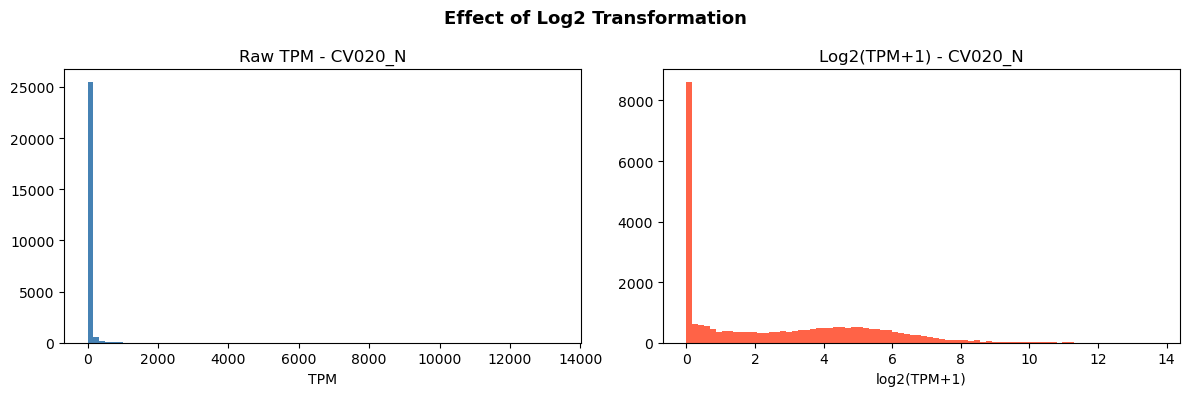

In [22]:
log_df = np.log2(df + 1)

# Quick check: distribution of a random sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_col = df.columns[0]
axes[0].hist(df[sample_col], bins=80, color='steelblue', edgecolor='none')
axes[0].set_title(f"Raw TPM - {sample_col}")
axes[0].set_xlabel("TPM")

axes[1].hist(log_df[sample_col], bins=80, color='tomato', edgecolor='none')
axes[1].set_title(f"Log2(TPM+1) - {sample_col}")
axes[1].set_xlabel("log2(TPM+1)")

plt.suptitle("Effect of Log2 Transformation", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Quality Control - PCA
PCA confirms that tumor and normal samples separate on the first principal component, validating sample grouping before statistical testing.

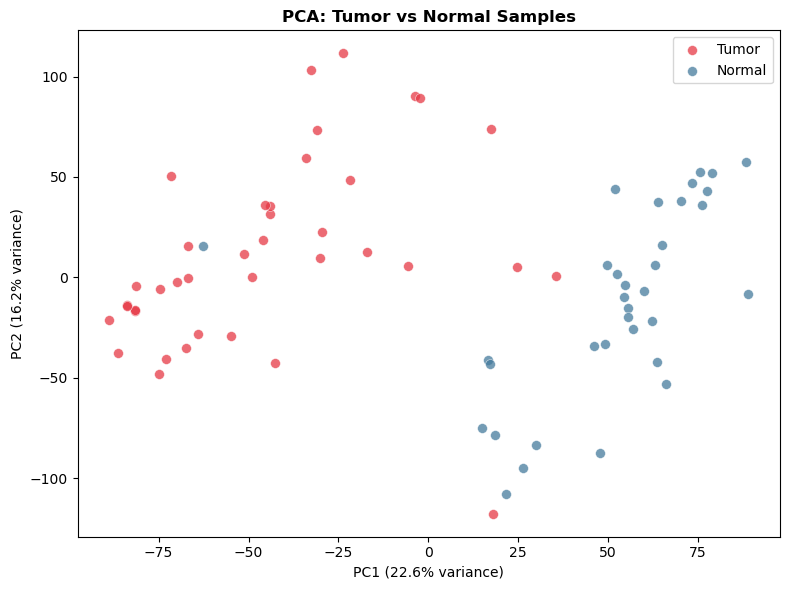

PC1 explains 22.6% of total variance
PC2 explains 16.2% of total variance


In [5]:
from sklearn.decomposition import PCA

# Subset and transpose: rows = samples, columns = genes
all_samples = tumor_samples + normal_samples
pca_input   = log_df[all_samples].T

pca    = PCA(n_components=2)
coords = pca.fit_transform(pca_input)

colors = ['#e63946' if s in tumor_samples else '#457b9d' for s in all_samples]
labels = ['Tumor' if s in tumor_samples else 'Normal' for s in all_samples]

plt.figure(figsize=(8, 6))
for color, label in [('#e63946', 'Tumor'), ('#457b9d', 'Normal')]:
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(coords[idx, 0], coords[idx, 1],
                c=color, label=label, alpha=0.75, s=50, edgecolors='white', linewidth=0.4)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA: Tumor vs Normal Samples", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of total variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of total variance")

## 6. Differential Expression Analysis - Welch's t-test + BH FDR Correction
Welch's t-test is used (no assumption of equal variance). Raw p-values are then corrected using the Benjamini-Hochberg (BH) procedure to control the false discovery rate (FDR). Without this correction, testing ~20,000 genes at p < 0.05 would yield ~1,000 false positives by chance alone.

In [23]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

normal_vals = log_df[normal_samples].values
tumor_vals  = log_df[tumor_samples].values

t_stat, p_values = ttest_ind(tumor_vals, normal_vals, axis=1, equal_var=False)

# Mean expression per group
tumor_mean  = df[tumor_samples].mean(axis=1)
normal_mean = df[normal_samples].mean(axis=1)
log2fc      = np.log2(tumor_mean + 1) - np.log2(normal_mean + 1)

results_df = pd.DataFrame({
    "Gene"   : df.index,
    "t_stat" : t_stat,
    "p_value": p_values,
    "log2FC" : log2fc.values
})

# Only correct non-NaN p-values
valid_mask = results_df['p_value'].notna()
p_adj_vals = np.full(len(results_df), np.nan)  # start all as NaN

_, p_adj_corrected, _, _ = multipletests(
    results_df.loc[valid_mask, 'p_value'], method='fdr_bh'
)
p_adj_vals[valid_mask] = p_adj_corrected
results_df['p_adj'] = p_adj_vals

# Report
results_df = results_df.sort_values('p_adj')

print(f"Total genes tested       : {len(results_df):,}")
print(f"Genes with NaN p-value   : {results_df['p_value'].isna().sum():,}  (excluded from FDR)")
print(f"Genes corrected          : {valid_mask.sum():,}")
print(f"adj. p < 0.05            : {(results_df['p_adj'] < 0.05).sum():,}")
print(f"|log2FC| > 1             : {(results_df['log2FC'].abs() > 1).sum():,}")
print(f"DEGs (both conditions)   : {((results_df['p_adj'] < 0.05) & (results_df['log2FC'].abs() > 1)).sum():,}")

Total genes tested       : 26,426
Genes with NaN p-value   : 2,090  (excluded from FDR)
Genes corrected          : 24,336
adj. p < 0.05            : 10,069
|log2FC| > 1             : 2,560
DEGs (both conditions)   : 2,430


## 7. Define DEGs and Split by Direction

In [13]:
# Standard DEG thresholds: adjusted p < 0.05 AND |log2FC| > 1 (i.e. 2-fold change)
degs = results_df[
    (results_df["p_adj"] < 0.05) &
    (abs(results_df["log2FC"]) > 1)
].copy()

upregulated   = degs[degs["log2FC"] >  1].sort_values("log2FC", ascending=False)
downregulated = degs[degs["log2FC"] < -1].sort_values("log2FC")

print(f"Total DEGs       : {len(degs):,}")
print(f"  Upregulated    : {len(upregulated):,}  (higher in tumor)")
print(f"  Downregulated  : {len(downregulated):,}  (lower in tumor)")

print("\nTop 10 upregulated genes:")
print(upregulated[["Gene","log2FC","p_adj"]].head(10).to_string(index=False))

print("\nTop 10 downregulated genes:")
print(downregulated[["Gene","log2FC","p_adj"]].head(10).to_string(index=False))

Total DEGs       : 2,430
  Upregulated    : 1,026  (higher in tumor)
  Downregulated  : 1,404  (lower in tumor)

Top 10 upregulated genes:
 Gene   log2FC        p_adj
REG1A 7.752640 4.133659e-10
NOTUM 6.478177 1.680352e-06
REG3A 6.258650 8.823997e-07
 TCN1 6.140052 9.805718e-06
 KLK6 6.030207 2.651313e-07
REG1B 5.977443 5.586849e-08
 HULC 5.959798 1.353999e-03
 CST1 5.335337 1.959183e-12
KRT6B 5.054290 1.343617e-06
 MMP7 5.030460 1.205465e-12

Top 10 downregulated genes:
 Gene    log2FC        p_adj
OTOP2 -5.628311 1.389227e-13
BEST4 -5.258469 2.429517e-13
  DES -5.138068 9.346487e-10
  CA7 -5.087483 3.364133e-14
MYH11 -4.693142 5.456454e-09
CLCA4 -4.687627 1.061597e-12
 CNN1 -4.630724 1.413758e-07
INSL5 -4.608100 1.772603e-06
ACTG2 -4.530061 1.067220e-06
  PYY -4.497101 9.344524e-13


## 8. Volcano Plot
The volcano plot displays all genes by fold change (x-axis) and statistical significance (y-axis). Red dots = upregulated in tumor; blue dots = downregulated in tumor; grey = not significant.

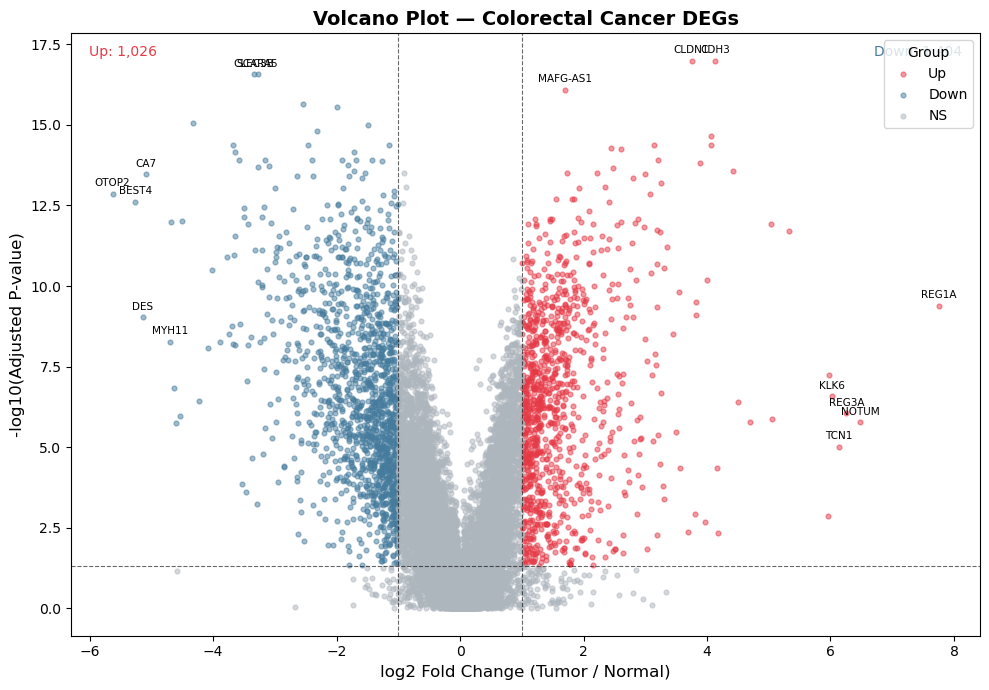

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))

# Classify each gene
def classify(row):
    if row['p_adj'] < 0.05 and row['log2FC'] >  1: return 'Up'
    if row['p_adj'] < 0.05 and row['log2FC'] < -1: return 'Down'
    return 'NS'

results_df['group'] = results_df.apply(classify, axis=1)
color_map = {'Up': '#e63946', 'Down': '#457b9d', 'NS': '#adb5bd'}

for grp, color in color_map.items():
    sub = results_df[results_df['group'] == grp]
    ax.scatter(sub['log2FC'], -np.log10(sub['p_adj']),
               c=color, alpha=0.5, s=12, label=grp, rasterized=True)

# Threshold lines
ax.axhline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline( 1, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(-1, color='black', linestyle='--', linewidth=0.8, alpha=0.6)

# Label top 15 genes (5 most up, 5 most down, 5 most significant)
top_label = pd.concat([
    upregulated.head(5),
    downregulated.head(5),
    degs.nsmallest(5, 'p_adj')
]).drop_duplicates('Gene')

for _, row in top_label.iterrows():
    ax.annotate(row['Gene'],
                xy=(row['log2FC'], -np.log10(row['p_adj'])),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')

ax.set_xlabel("log2 Fold Change (Tumor / Normal)", fontsize=12)
ax.set_ylabel("-log10(Adjusted P-value)", fontsize=12)
ax.set_title("Volcano Plot — Colorectal Cancer DEGs", fontsize=14, fontweight='bold')
ax.legend(title="Group", frameon=True)

# Annotation counts
ax.text(0.02, 0.98, f"Up: {len(upregulated):,}",
        transform=ax.transAxes, va='top', color='#e63946', fontsize=10)
ax.text(0.98, 0.98, f"Down: {len(downregulated):,}",
        transform=ax.transAxes, va='top', ha='right', color='#457b9d', fontsize=10)

plt.tight_layout()
plt.show()

## 9. KEGG Pathway Enrichment Analysis
Enrichment is run separately for upregulated and downregulated DEGs to identify distinct biological processes activated or suppressed in colorectal tumors.

In [15]:
import gseapy as gp

up_genes   = upregulated['Gene'].tolist()
down_genes = downregulated['Gene'].tolist()

print(f"Running Enrichr on {len(up_genes)} upregulated genes...")
enr_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets=['KEGG_2021_Human'],
    organism='h. sapiens',
    outdir=None
)

print(f"Running Enrichr on {len(down_genes)} downregulated genes...")
enr_down = gp.enrichr(
    gene_list=down_genes,
    gene_sets=['KEGG_2021_Human'],
    organism='h. sapiens',
    outdir=None
)

top_up   = enr_up.results.sort_values('Adjusted P-value').head(10)
top_down = enr_down.results.sort_values('Adjusted P-value').head(10)

print("\nTop enriched pathways — UPREGULATED genes:")
print(top_up[['Term', 'Adjusted P-value', 'Overlap']].to_string(index=False))

print("\nTop enriched pathways — DOWNREGULATED genes:")
print(top_down[['Term', 'Adjusted P-value', 'Overlap']].to_string(index=False))

Running Enrichr on 1026 upregulated genes...
Running Enrichr on 1404 downregulated genes...

Top enriched pathways — UPREGULATED genes:
                                  Term  Adjusted P-value Overlap
                            Cell cycle      4.477731e-12  32/124
                       DNA replication      1.719207e-05   12/36
               IL-17 signaling pathway      1.073391e-04   18/94
                  Rheumatoid arthritis      1.301369e-03   16/93
                 p53 signaling pathway      4.288980e-03   13/73
Cytokine-cytokine receptor interaction      1.334518e-02  30/295
      Protein digestion and absorption      2.475352e-02  14/103
                       Mismatch repair      2.475352e-02    6/23
                 Wnt signaling pathway      2.475352e-02  19/166
                        Bladder cancer      2.475352e-02    8/41

Top enriched pathways — DOWNREGULATED genes:
                                 Term  Adjusted P-value Overlap
                   Mineral absorption  

## 10. Pathway Enrichment Bar Charts

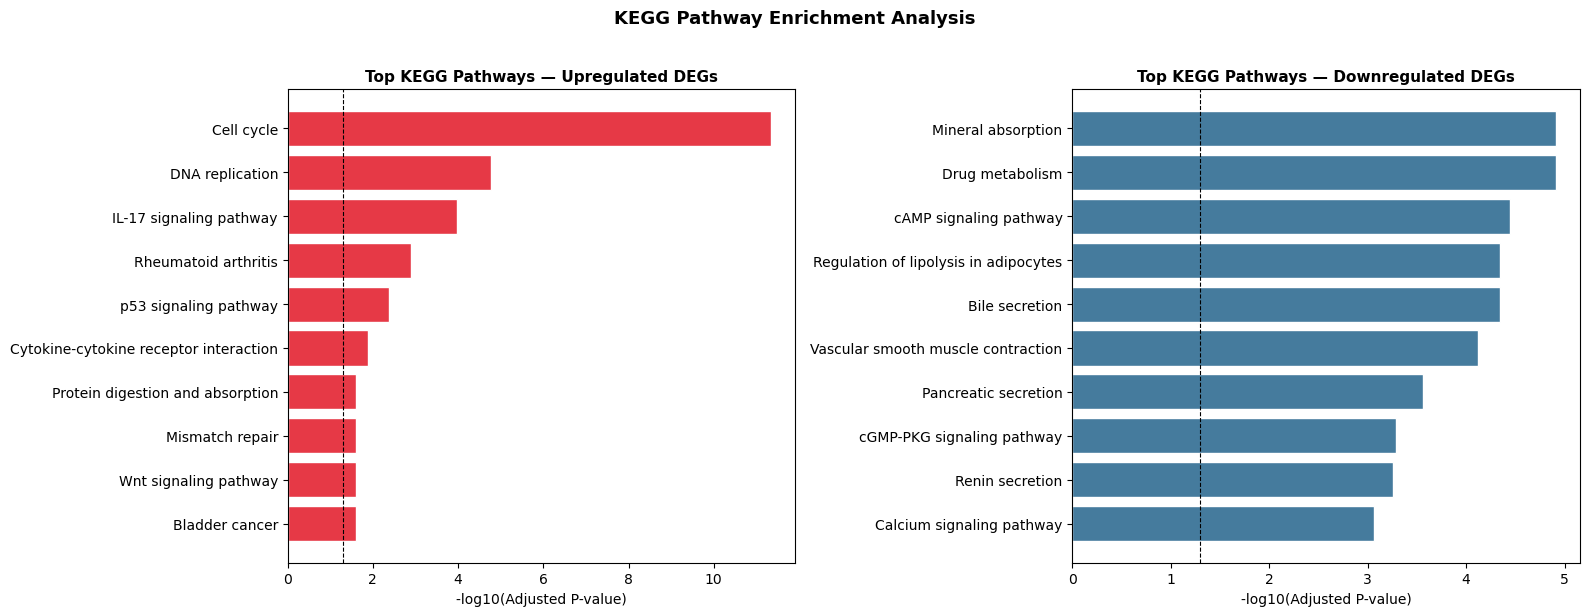

In [16]:
def plot_enrichment_bar(df_enr, title, color, ax):
    df_enr = df_enr.copy()
    # Shorten term names for readability
    df_enr['Short Term'] = df_enr['Term'].str.replace(r' Homo.*$','', regex=True).str[:55]
    df_enr = df_enr.sort_values('Adjusted P-value')
    y = -np.log10(df_enr['Adjusted P-value'].clip(lower=1e-300))
    ax.barh(df_enr['Short Term'], y, color=color, edgecolor='white')
    ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=0.8)
    ax.invert_yaxis()
    ax.set_xlabel("-log10(Adjusted P-value)", fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_enrichment_bar(top_up,   "Top KEGG Pathways — Upregulated DEGs",   '#e63946', axes[0])
plot_enrichment_bar(top_down, "Top KEGG Pathways — Downregulated DEGs", '#457b9d', axes[1])

plt.suptitle("KEGG Pathway Enrichment Analysis", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Gene Ontology (Biological Process) Enrichment

Running GO Biological Process enrichment on upregulated genes...


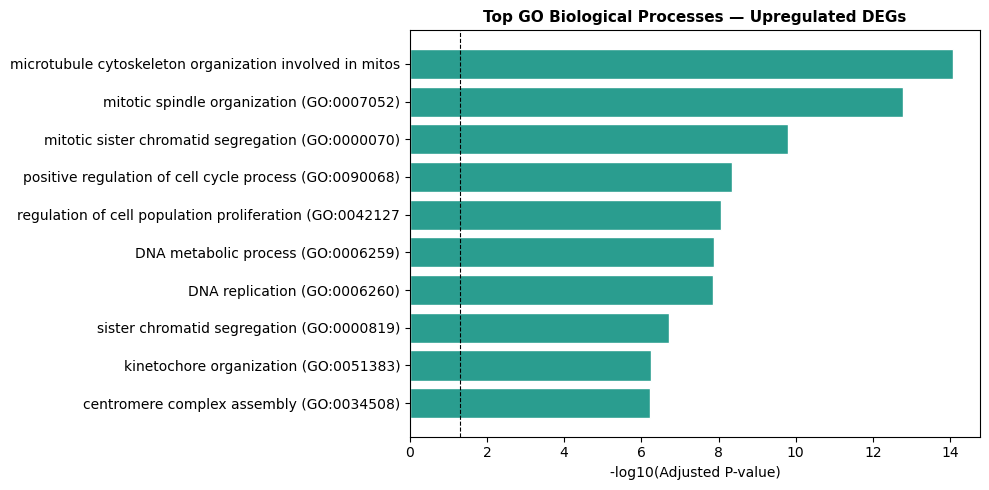

In [17]:
print("Running GO Biological Process enrichment on upregulated genes...")
enr_go_up = gp.enrichr(
    gene_list=up_genes,
    gene_sets=['GO_Biological_Process_2021'],
    organism='h. sapiens',
    outdir=None
)

top_go_up = enr_go_up.results.sort_values('Adjusted P-value').head(10)

fig, ax = plt.subplots(figsize=(10, 5))
plot_enrichment_bar(top_go_up, "Top GO Biological Processes — Upregulated DEGs", '#2a9d8f', ax)
plt.tight_layout()
plt.show()

## 12. Heatmap - Top 50 DEGs (Stringent Filtering)
Rows = top 50 most significant DEGs (adj. p < 0.05, |log2FC| > 1). Columns = all samples. Colour = z-scored expression. Clustering reveals groups of co-expressed genes and confirms tumor/normal separation.

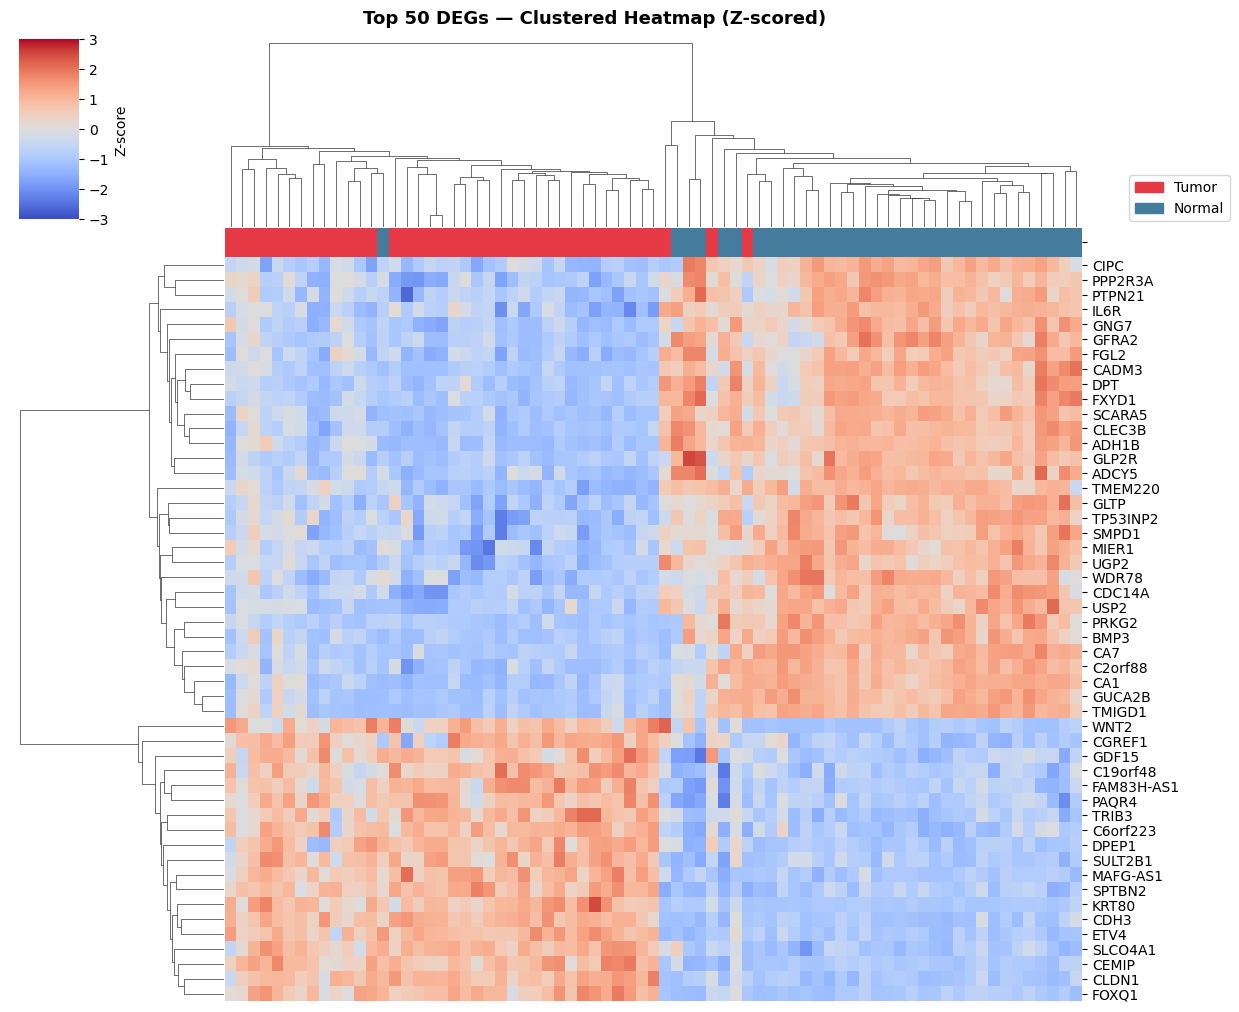

In [18]:
from sklearn.preprocessing import StandardScaler

# Take the top 50 DEGs by adjusted p-value
top50_genes = degs.nsmallest(50, 'p_adj')['Gene'].tolist()
top50_genes = [g for g in top50_genes if g in df.index]  # safety check

# Subset expression and z-score across samples
heatmap_raw = df.loc[top50_genes, all_samples]
log_heatmap = np.log2(heatmap_raw + 1)

scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(log_heatmap.T).T,
    index=log_heatmap.index,
    columns=log_heatmap.columns
)

# Column colour bar: tumor = red, normal = blue
col_colors = pd.Series(
    ['#e63946' if s in tumor_samples else '#457b9d' for s in scaled.columns],
    index=scaled.columns
)

g = sns.clustermap(
    scaled,
    cmap='coolwarm',
    figsize=(12, 10),
    col_colors=col_colors,
    yticklabels=True,
    xticklabels=False,
    cbar_kws={'label': 'Z-score'},
    vmin=-3, vmax=3
)
g.fig.suptitle("Top 50 DEGs — Clustered Heatmap (Z-scored)",
               y=1.01, fontsize=13, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_handles = [Patch(color='#e63946', label='Tumor'),
                  Patch(color='#457b9d', label='Normal')]
g.ax_heatmap.legend(handles=legend_handles, loc='upper right',
                    bbox_to_anchor=(1.18, 1.12), frameon=True)
plt.show()

## 13. Heatmap - Genes from Top 5 KEGG Pathways
This heatmap shows the expression of all genes belonging to the top 5 enriched KEGG pathways (upregulated), revealing coordinated pathway-level expression changes.

Unique pathway genes present in expression matrix: 71


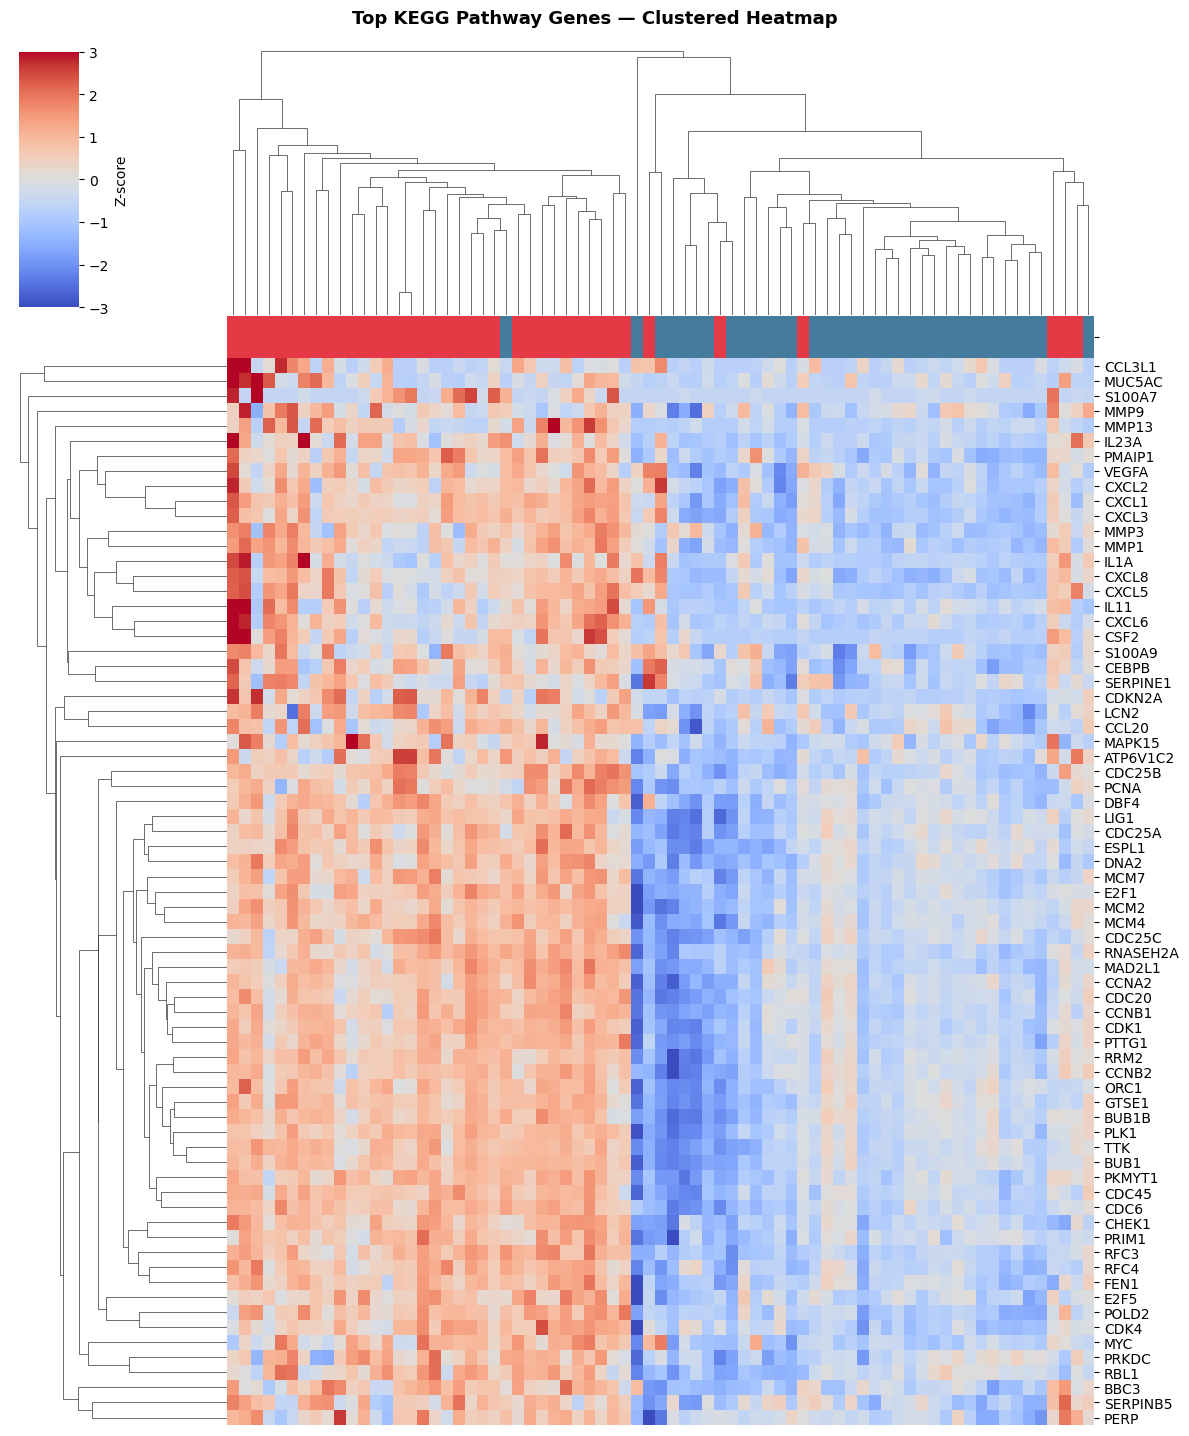

In [19]:
# Gather genes from top 5 upregulated KEGG pathways
pathway_gene_set = set()
for _, row in enr_up.results.sort_values('Adjusted P-value').head(5).iterrows():
    pathway_gene_set.update(row['Genes'].split(";"))

pathway_gene_set = [g for g in pathway_gene_set if g in df.index]
print(f"Unique pathway genes present in expression matrix: {len(pathway_gene_set)}")

pw_raw    = df.loc[pathway_gene_set, all_samples]
log_pw    = np.log2(pw_raw + 1)
scaled_pw = pd.DataFrame(
    scaler.fit_transform(log_pw.T).T,
    index=log_pw.index, columns=log_pw.columns
)

g2 = sns.clustermap(
    scaled_pw,
    cmap='coolwarm',
    figsize=(12, max(6, len(pathway_gene_set) * 0.2)),
    col_colors=col_colors,
    yticklabels=True,
    xticklabels=False,
    cbar_kws={'label': 'Z-score'},
    vmin=-3, vmax=3
)
g2.fig.suptitle("Top KEGG Pathway Genes — Clustered Heatmap",
                y=1.01, fontsize=13, fontweight='bold')
plt.show()

## 14. Summary Statistics Table

In [20]:
summary = pd.DataFrame({
    "Metric": [
        "Total genes tested",
        "Tumor samples",
        "Normal samples",
        "DEGs (adj. p < 0.05, |log2FC| > 1)",
        "Upregulated",
        "Downregulated",
        "Top upregulated gene",
        "Top downregulated gene",
        "Top enriched KEGG pathway (up)",
        "Top enriched KEGG pathway (down)"
    ],
    "Value": [
        f"{len(results_df):,}",
        str(len(tumor_samples)),
        str(len(normal_samples)),
        f"{len(degs):,}",
        f"{len(upregulated):,}",
        f"{len(downregulated):,}",
        upregulated.iloc[0]['Gene'] if len(upregulated) > 0 else 'N/A',
        downregulated.iloc[0]['Gene'] if len(downregulated) > 0 else 'N/A',
        enr_up.results.iloc[0]['Term']   if len(enr_up.results)   > 0 else 'N/A',
        enr_down.results.iloc[0]['Term'] if len(enr_down.results) > 0 else 'N/A'
    ]
})

print("=" * 65)
print("          ANALYSIS SUMMARY — CRC RNA-seq (GSE292858)")
print("=" * 65)
print(summary.to_string(index=False))
print("=" * 65)

          ANALYSIS SUMMARY — CRC RNA-seq (GSE292858)
                            Metric              Value
                Total genes tested             26,426
                     Tumor samples                 39
                    Normal samples                 34
DEGs (adj. p < 0.05, |log2FC| > 1)              2,430
                       Upregulated              1,026
                     Downregulated              1,404
              Top upregulated gene              REG1A
            Top downregulated gene              OTOP2
    Top enriched KEGG pathway (up)         Cell cycle
  Top enriched KEGG pathway (down) Mineral absorption


## 15. Export Results to CSV

In [21]:
import os
OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

# Full DE results
results_df.to_csv(f"{OUT_DIR}/all_genes_DE_results.csv", index=False)

# DEGs only
degs.to_csv(f"{OUT_DIR}/DEGs_filtered.csv", index=False)
upregulated.to_csv(f"{OUT_DIR}/DEGs_upregulated.csv", index=False)
downregulated.to_csv(f"{OUT_DIR}/DEGs_downregulated.csv", index=False)

# Pathway results
enr_up.results.to_csv(f"{OUT_DIR}/KEGG_enrichment_upregulated.csv", index=False)
enr_down.results.to_csv(f"{OUT_DIR}/KEGG_enrichment_downregulated.csv", index=False)
enr_go_up.results.to_csv(f"{OUT_DIR}/GO_BP_enrichment_upregulated.csv", index=False)

print("Results saved to:")
for f in os.listdir(OUT_DIR):
    print(f"  {OUT_DIR}/{f}")

Results saved to:
  results/all_genes_DE_results.csv
  results/DEGs_downregulated.csv
  results/DEGs_filtered.csv
  results/DEGs_upregulated.csv
  results/GO_BP_enrichment_upregulated.csv
  results/KEGG_enrichment_downregulated.csv
  results/KEGG_enrichment_upregulated.csv


## Conclusions

### 1. Sample quality and group separation

PCA of the log2-transformed TPM data revealed that PC1 alone explained 22.6% of total transcriptome variance, and tumor and normal samples formed two clearly separable clusters along this axis. This confirms that the dominant source of variation in the dataset is biological (tumor vs. normal tissue), not technical noise or residual batch effects, and validates the groupings before any statistical testing.

### 2. Differential expression landscape

After applying Welch's t-test with Benjamini-Hochberg FDR correction, 2,430 genes met the stringent DEG threshold of adjusted p < 0.05 and |log2FC| > 1 (2-fold change). Of these, 1,026 were upregulated in tumor tissue and 1,404 were downregulated, indicating that CRC is characterized by broader transcriptional suppression than activation relative to matched normal mucosa, a pattern consistent with the widespread loss of differentiated colonocyte function as cells undergo malignant transformation.

### 3. Top upregulated genes

The most strongly upregulated gene was _REG1A_ (log2FC = 7.75), followed closely by _REG3A_ (log2FC = 6.26) and _REG1B_ (log2FC = 5.98). These three belong to the Regenerating gene (REG) family, which encodes small secreted proteins. REG1A has been validated as significantly upregulated in CRC tumor specimens compared to normal colorectal tissue, with a diagnostic sensitivity of 90.6% and specificity of 77.9%, and elevated expression has been linked to peritoneal carcinomatosis and shorter disease-free survival. REG3A overexpression promotes CRC tumorigenesis by activating AKT and ERK1/2 pathways, and its knockdown in CRC cell lines significantly inhibits proliferation, migration, and invasion. The co-upregulation of REG1A, REG1B, and REG3A in this dataset is therefore strongly consistent with the published CRC literature and lends biological credibility to the analysis.

_MMP7_ (log2FC = 5.03) was also among the top upregulated genes. MMP7 (matrilysin) is frequently overexpressed in human cancer tissues, and its expression correlates significantly with nodal and distant metastases in colorectal cancer. Its upregulation here aligns with the known role of MMP7 in ECM remodeling and tumor invasion. _NOTUM_ (log2FC = 6.48) is a Wnt signaling regulator whose upregulation is consistent with the broader Wnt pathway enrichment seen in the pathway analysis below.

### 4. Top downregulated genes

The most strongly downregulated genes included _OTOP2_ (log2FC = −5.63), _BEST4_ (log2FC = −5.26), _CA7_ (log2FC = −5.09), _DES_ (log2FC = −5.14), _MYH11_ (log2FC = −4.69), and _CLCA4_ (log2FC = −4.69). These genes collectively reflect the loss of normal colonocyte identity in tumor tissue. _BEST4_ and _OTOP2_ mark a specialized population of proton-sensing colonocytes that are among the first cell types lost during CRC progression. _CA7_ encodes carbonic anhydrase VII, whose loss impairs normal ionic homeostasis in the colon. _DES_, _MYH11_, and _ACTG2_ are structural proteins of smooth muscle and stromal cells, and their suppression reflects the disruption of normal tissue architecture in the tumor microenvironment. The loss of these colonocyte-identity genes is a hallmark of CRC and is well-documented in the literature.

### 5. Pathway enrichment analysis

**Upregulated pathways:** The most significantly enriched KEGG pathway among upregulated genes was the Cell cycle (adjusted p = 4.5 × 10⁻¹²), with 32 of 124 pathway genes dysregulated. This is the single most expected finding in any cancer transcriptome: uncontrolled cell cycle progression is a defining feature of malignancy. DNA replication (adjusted p = 1.7 × 10⁻⁵) was the second most enriched pathway, reinforcing the picture of accelerated tumor cell division. The enrichment of IL-17 signaling (adjusted p = 1.1 × 10⁻⁴) points to an active inflammatory microenvironment in CRC tumors, consistent with the well-established link between colonic inflammation and colorectal carcinogenesis. p53 signaling (adjusted p = 4.3 × 10⁻³) and Wnt signaling (adjusted p = 2.5 × 10⁻²) are two of the most canonically altered pathways in CRC, and their enrichment here further validates the biological coherence of the results.

**Downregulated pathways:** The top suppressed pathways were Mineral absorption (adjusted p = 1.2 × 10⁻⁵) and Drug metabolism (adjusted p = 1.2 × 10⁻⁵). Mineral absorption covers solute carrier transporters and ion channels essential to normal colonocyte function; their suppression is consistent with the loss of absorptive epithelial identity seen in CRC. Drug metabolism pathway suppression reflects the reduced expression of cytochrome P450 enzymes and conjugating enzymes that are normally highly active in colon mucosa. The suppression of cAMP signaling (adjusted p = 3.6 × 10⁻⁵), Bile secretion (adjusted p = 4.5 × 10⁻⁵), and Calcium signaling (adjusted p = 8.6 × 10⁻⁴) further reflects the global dedifferentiation of colonocytes toward a less specialized, more proliferative phenotype.

### 6. Heatmap clustering

Hierarchical clustering of the top 50 DEGs cleanly separated tumor and normal samples into two distinct groups without any supervised labeling, which confirms that the expression differences identified statistically are also structurally robust. The coolwarm pattern in the clustermap - a block of genes overexpressed in tumors (warm) and a separate block overexpressed in normal tissue (cool) - visually mirrors the two-group structure of the pathway enrichment results.

### 7. Limitations

This analysis uses TPM-normalized data tested with Welch's t-test. While appropriate for normalized continuous data, count-based tools such as DESeq2 or edgeR operate on raw integer counts and use negative binomial modeling, which better accounts for overdispersion in RNA-seq data and is considered the current gold standard. Results here should therefore be treated as exploratory. Additionally, the dataset consists of a single cohort (GSE292858), so findings should be validated in an independent dataset such as TCGA-COAD. No clinical annotations (tumor stage, microsatellite instability status, mutation profile) were incorporated, which limits the ability to stratify results by molecular subtype. Future work could integrate TCGA clinical data to test whether the top DEGs are associated with patient survival, and could extend the pathway analysis to include transcription factor enrichment (ChEA) or protein-protein interaction network analysis via STRING.

### 8. Overall conclusion

This RNA-seq analysis of 39 colorectal tumor and 34 matched normal tissue samples from GEO dataset GSE292858 identified 2,430 robust DEGs, dominated by upregulation of REG family proliferation drivers (REG1A, REG3A, REG1B) and MMP7, and downregulation of colonocyte-identity genes (BEST4, OTOP2, CA7). Pathway enrichment confirms activation of core oncogenic programs: cell cycle, DNA replication, Wnt, and p53 signaling, alongside suppression of normal colonic physiology. The results are highly consistent with the established molecular landscape of colorectal cancer and demonstrate a complete, reproducible Python-based DEA pipeline from raw TPM data to biological interpretation.